# DeepExtractor Example

This notebook features an example of using DeepExtractor on simulated LIGO noise. 

We will also simulate Virgo noise to see how the LIGO-trained model works.

## Imports

We will keep things minimal

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import matplotlib.pyplot as plt
from deepextractor.utils.visualization import plot_q_transform
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import scienceplots

plt.style.use(['science'])
plt.rcParams['text.usetex'] = False  # Set to True for LaTeX-rendered plots

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [4]:
import os
import pickle
import numpy as np
import pandas as pd
import torch
import bilby
from tqdm import tqdm

from deepextractor.models import UNET2D
from deepextractor.utils.checkpoints import load_torch_model, CHECKPOINT_BILBY
from deepextractor.generation.glitch_functions import (
    generate_chirp, generate_sine, generate_sine_gaussian,
    generate_gaussian_pulse, ringdown, generate_gengli_glitch,
)
from deepextractor.generation.generate_timeseries import generate_synthetic_data, generate_gaussian_noise, SNR_SCALING_FACTOR_BILBY
from deepextractor.evaluation.simulate import (
    generate_glitch_data, apply_stft, apply_istft,
    prepare_data_for_stft, calculate_match,
)

## Parameters

In [5]:
SAMPLE_RATE = 4096
NYQUIST_FREQUENCY = SAMPLE_RATE / 2
DURATION = 2.
DATA_PATH = 'data/'

# Path to assets directory (scalers, etc.)
ASSETS_DIR = os.path.join(os.path.dirname(os.getcwd()), 'assets') if os.path.isdir(
    os.path.join(os.path.dirname(os.getcwd()), 'assets')
) else '../../assets'

## Simulated glitches

We will just look at the training glitches to keep things simple


In [6]:
# Glitch generators are already imported in the imports cell above

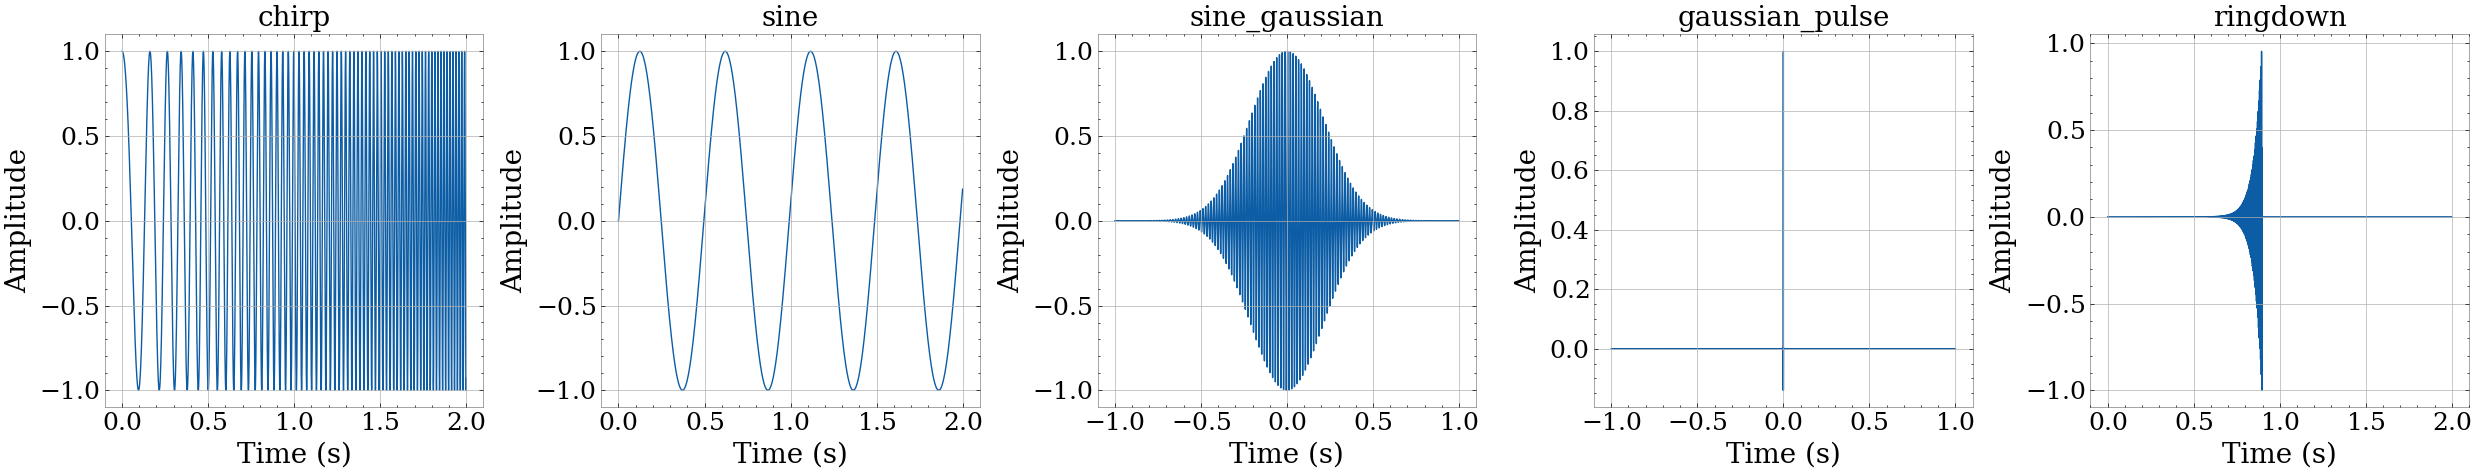

In [7]:
duration = 2. # We consider 2s samples
max_freq = 64 # We keep a low max frequency for the purposes of visualization

# Here are our 5 training classes
signal_types = ['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown']
signal_function_map = {
    'chirp': generate_chirp(duration, f0_min=1, f0_max=5, f1_min=1, f1_max=max_freq),
    'sine': generate_sine(duration, freq_min=1, freq_max=32),
    'sine_gaussian': generate_sine_gaussian(duration, freq_max=max_freq),
    'gaussian_pulse': generate_gaussian_pulse(duration),
    'ringdown': ringdown(duration)
}

# Create plots for each class
fig, axes = plt.subplots(1, len(signal_types), figsize=(25, 5))
for i, signal_type in enumerate(signal_types):
    t, signal = signal_function_map[signal_type]
    axes[i].plot(t, signal)
    axes[i].set_title(signal_type, fontsize=20)
    axes[i].set_xlabel('Time (s)', fontsize=20)
    axes[i].set_ylabel('Amplitude', fontsize=20)
    axes[i].tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.show()

### Scaling the data and generating STFT maps


In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
# Let's start by defining some parameters
SAMPLE_RATE = 4096
NYQUIST_FREQ = SAMPLE_RATE // 2
T_MIN, T_MAX = 0.125, 2  # Duration range for glitch signals
T = 2.0  # Total duration in seconds
T_INJ = T / 2  # Injection time midpoint
LENGTH = int(T * SAMPLE_RATE)
MEAN = 0
STD_DEV = np.sqrt(SAMPLE_RATE/2) # PyCBC standards
NUM_SAMPLES = 10 # Let's just generate a few examples
BILBY_NOISE = True # We will use Bilby noise for this example
SNR_MIN, SNR_MAX = 1, 250  # SNR range for glitch scaling
MINIMUM_FREQUENCY = 20. # This is for BayesWave comparison
SNR_SCALING_FACTOR_BILBY = 31.970149253731343 # This scaling factor for Bilby to make sure SNR aligns with PyCBC

## We will define a new function for generating noise that allows us to control the detector

In [ ]:
# generate_gaussian_noise is imported from deepextractor.generation.generate_timeseries

In [25]:
signal_types = ['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown']
signal_function_map = {
    'chirp': generate_chirp,
    'sine': generate_sine,
    'sine_gaussian': generate_sine_gaussian,
    'gaussian_pulse': generate_gaussian_pulse,
    'ringdown': ringdown,
}

gaussian_noise_samples = generate_gaussian_noise(MEAN, STD_DEV, NUM_SAMPLES, (LENGTH,), bilby_noise=BILBY_NOISE)
h_t, n_t = generate_synthetic_data(gaussian_noise_samples, bilby_noise=BILBY_NOISE, phase='examples')

# Load the bilby noise scaler (paired with checkpoint_best_bilby_noise_base.pth.tar)
scaler_path = os.path.join(ASSETS_DIR, 'scaler_bilby.pkl')
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

h_t_scaled = scaler.fit_transform(h_t.reshape(-1, 1)).reshape(h_t.shape)
n_t_scaled = scaler.transform(n_t.reshape(-1, 1)).reshape(n_t.shape)

Generating Synthetic Examples Data: 100%|██████████| 10/10 [00:00<00:00, 457.85it/s]
/opt/homebrew/Caskroom/miniforge/base/envs/deepextractor-test/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


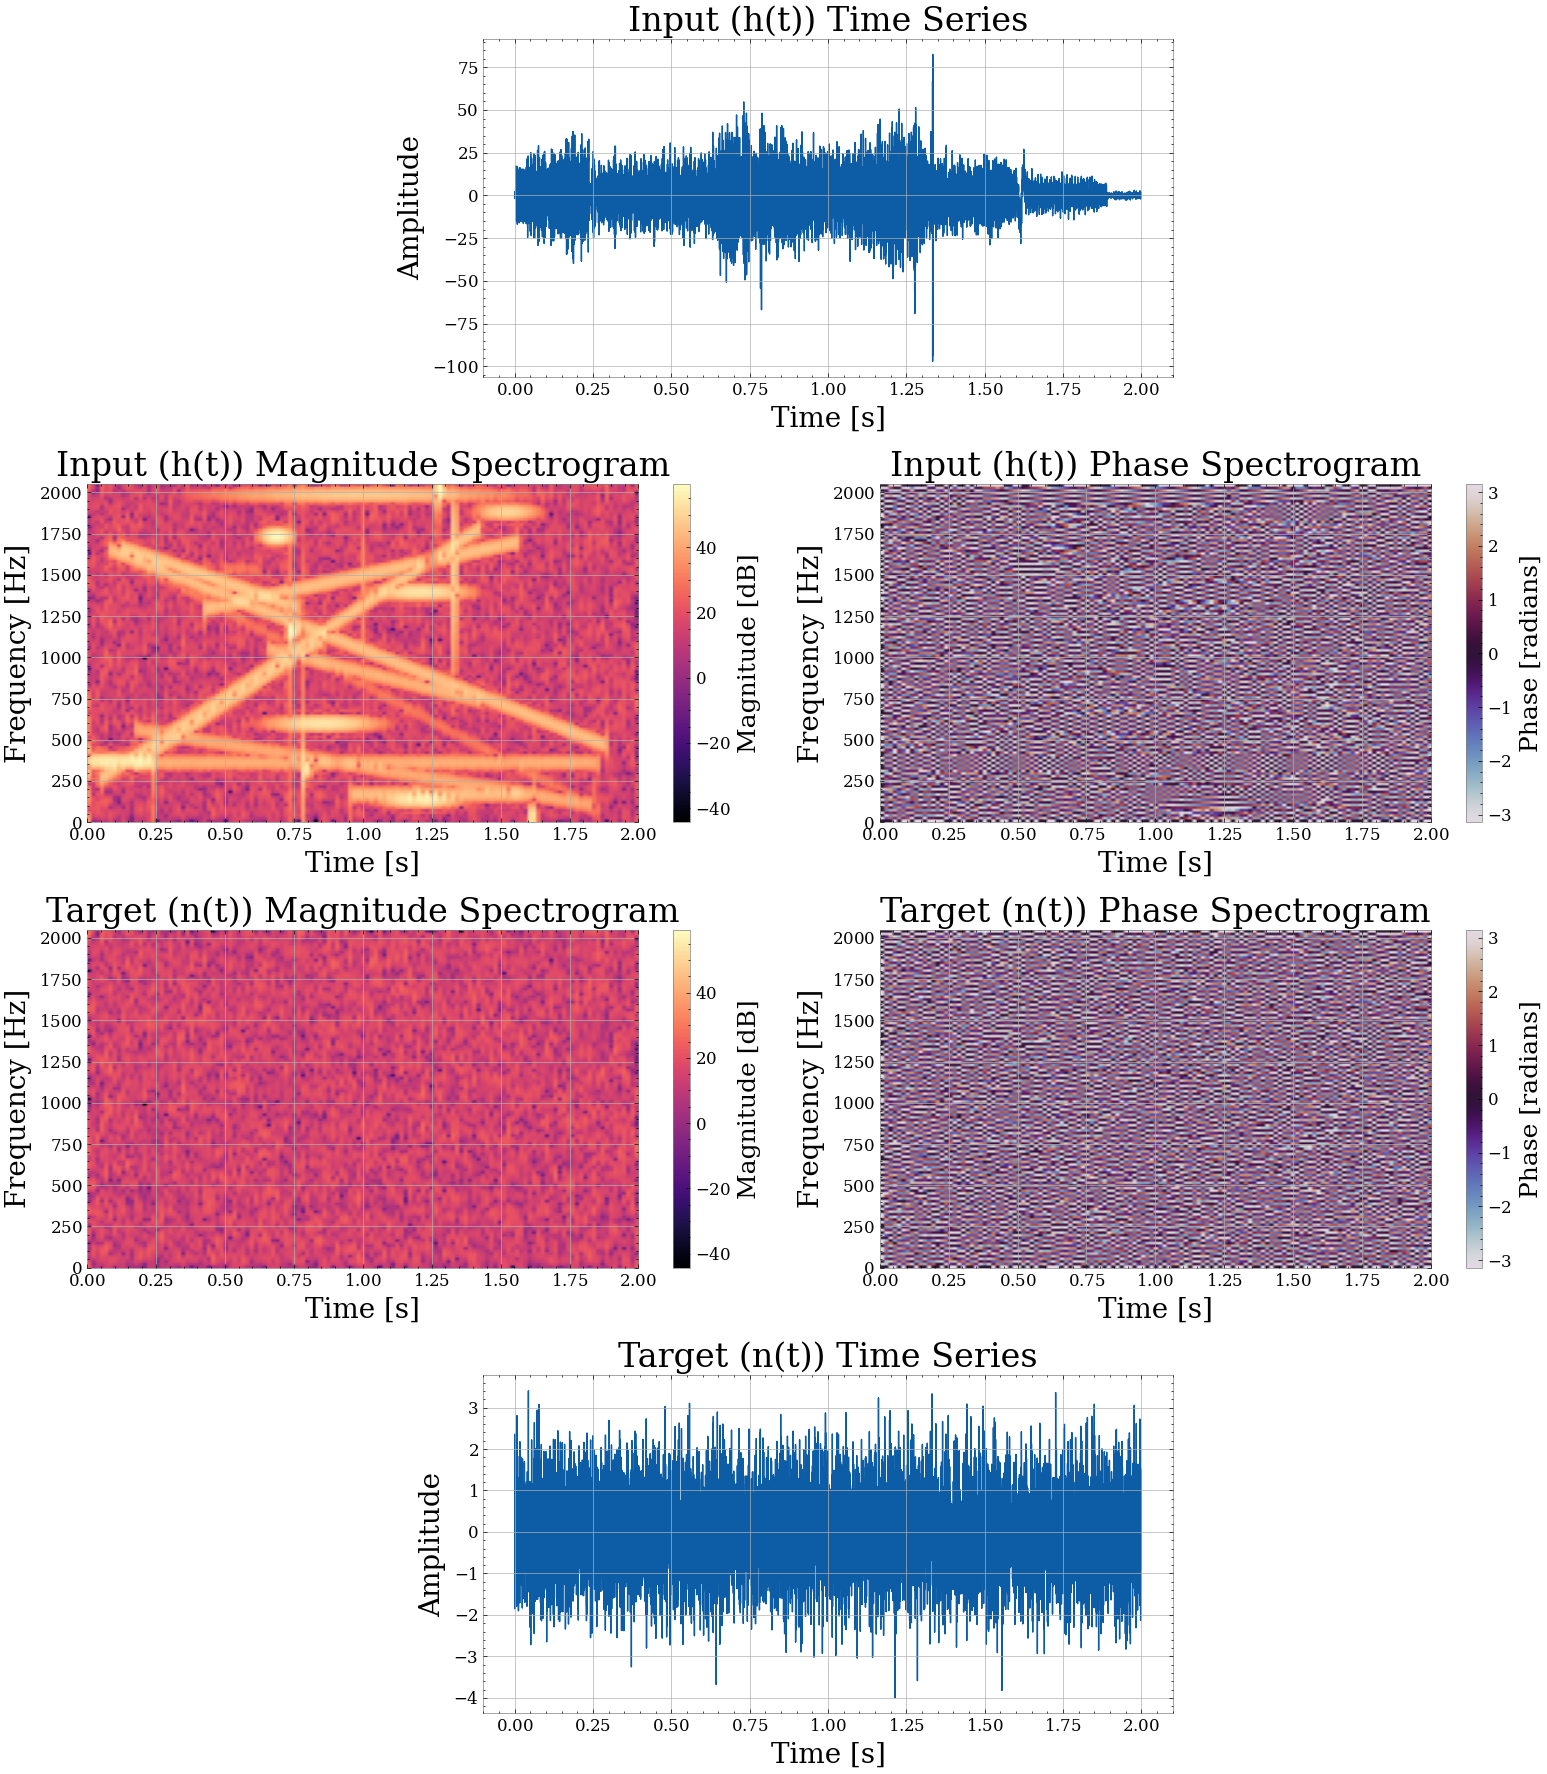

In [26]:
# Now let's generate the time-frequency (spectrogram) data, h(t, f) and n(t, f), from h(t) and n(t).
# We do have scripts that do this already, but due to the large memory required for generating full training sets, there are some intermediate steps where data is created and deleted where required.
# As a result, we will just process one example below following these steps.

# Let's start by defining some STFT parameters. We will choose those to generate 129x129 specs
n_fft = 256  
win_length = n_fft // 2  
hop_length = win_length // 2  
window = torch.hann_window(win_length)

# Extract the first index of the time series samples
h_t_sample = h_t[0]
n_t_sample = n_t[0]

h_t_tensor = torch.tensor(h_t, dtype=torch.float32)
n_t_tensor = torch.tensor(n_t, dtype=torch.float32)

# STFT computation
h_stft_tensor = torch.stft(h_t_tensor, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window, return_complex=True)
n_stft_tensor = torch.stft(n_t_tensor, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window, return_complex=True)

# Compute magnitude and phase
h_stft_magnitude = torch.abs(h_stft_tensor).numpy()  
h_stft_phase = torch.angle(h_stft_tensor).numpy()  
n_stft_magnitude = torch.abs(n_stft_tensor).numpy()
n_stft_phase = torch.angle(n_stft_tensor).numpy()

sample_index = 0  # Choose the first sample as an example
time_td = np.linspace(0, len(h_t_sample) / SAMPLE_RATE, len(h_t_sample))

# Time and frequency axes
num_time_bins = h_stft_magnitude.shape[2]  # Number of time bins
time = np.linspace(0, 2, num_time_bins)  # Time from 0 to 2 seconds
num_freq_bins = h_stft_magnitude.shape[1]  # Number of frequency bins
freq = np.linspace(0, NYQUIST_FREQUENCY, num_freq_bins)  # Frequency from 0 to Nyquist frequency

# Calculate dB magnitude for glitch and background, and find shared color scale limits
h_stft_magnitude_sample = h_stft_magnitude[sample_index]
h_stft_phase_sample = h_stft_phase[sample_index]
n_stft_magnitude_sample = n_stft_magnitude[sample_index]
n_stft_phase_sample = n_stft_phase[sample_index]

# Convert magnitudes to dB
h_stft_magnitude_sample_db = 20 * np.log10(h_stft_magnitude_sample + 1e-8)
n_stft_magnitude_sample_db = 20 * np.log10(n_stft_magnitude_sample + 1e-8)

# Determine global color scale limits across both glitch and background samples
vmin, vmax = min(h_stft_magnitude_sample_db.min(), n_stft_magnitude_sample_db.min()), max(h_stft_magnitude_sample_db.max(), n_stft_magnitude_sample_db.max())

# Create a grid layout
fig = plt.figure(figsize=(16, 18))
gs = GridSpec(4, 4, figure=fig)  # Create a 4x4 grid

# Input time series spanning across the top
ax_input_ts = fig.add_subplot(gs[0, 1:3])
ax_input_ts.plot(time_td, h_t_sample)
ax_input_ts.set_title("Input (h(t)) Time Series", fontsize=24)
ax_input_ts.set_xlabel("Time [s]", fontsize=20)
ax_input_ts.set_ylabel("Amplitude", fontsize=20)
ax_input_ts.grid(True)

# Input Magnitude Spectrogram
ax_input_magnitude = fig.add_subplot(gs[1, 0:2])
im1 = ax_input_magnitude.imshow(h_stft_magnitude_sample_db, aspect='auto', origin='lower', cmap='magma',
                                extent=[time[0], time[-1], freq[0], freq[-1]], vmin=vmin, vmax=vmax)
ax_input_magnitude.set_title("Input (h(t)) Magnitude Spectrogram", fontsize=24)
ax_input_magnitude.set_ylabel('Frequency [Hz]', fontsize=20)
ax_input_magnitude.set_xlabel('Time [s]', fontsize=20)
cb1 = fig.colorbar(im1, ax=ax_input_magnitude)
cb1.set_label('Magnitude [dB]', fontsize=18)

# Input Phase Spectrogram
ax_input_phase = fig.add_subplot(gs[1, 2:])
im2 = ax_input_phase.imshow(h_stft_phase_sample, aspect='auto', origin='lower', cmap='twilight',
                            extent=[time[0], time[-1], freq[0], freq[-1]], vmin=-np.pi, vmax=np.pi)
ax_input_phase.set_title("Input (h(t)) Phase Spectrogram", fontsize=24)
ax_input_phase.set_ylabel('Frequency [Hz]', fontsize=20)
ax_input_phase.set_xlabel('Time [s]', fontsize=20)
cb2 = fig.colorbar(im2, ax=ax_input_phase)
cb2.set_label('Phase [radians]', fontsize=18)

# Target Magnitude Spectrogram
ax_target_magnitude = fig.add_subplot(gs[2, 0:2])
im3 = ax_target_magnitude.imshow(n_stft_magnitude_sample_db, aspect='auto', origin='lower', cmap='magma',
                                 extent=[time[0], time[-1], freq[0], freq[-1]], vmin=vmin, vmax=vmax)
ax_target_magnitude.set_title("Target (n(t)) Magnitude Spectrogram", fontsize=24)
ax_target_magnitude.set_ylabel('Frequency [Hz]', fontsize=20)
ax_target_magnitude.set_xlabel('Time [s]', fontsize=20)
cb3 = fig.colorbar(im3, ax=ax_target_magnitude)
cb3.set_label('Magnitude [dB]', fontsize=18)

# Target Phase Spectrogram
ax_target_phase = fig.add_subplot(gs[2, 2:])
im4 = ax_target_phase.imshow(n_stft_phase_sample, aspect='auto', origin='lower', cmap='twilight',
                             extent=[time[0], time[-1], freq[0], freq[-1]], vmin=-np.pi, vmax=np.pi)
ax_target_phase.set_title("Target (n(t)) Phase Spectrogram", fontsize=24)
ax_target_phase.set_ylabel('Frequency [Hz]', fontsize=20)
ax_target_phase.set_xlabel('Time [s]', fontsize=20)
cb4 = fig.colorbar(im4, ax=ax_target_phase)
cb4.set_label('Phase [radians]', fontsize=18)

# Target time series spanning across the bottom
ax_target_ts = fig.add_subplot(gs[3, 1:3])
ax_target_ts.plot(time_td, n_t_sample)
ax_target_ts.set_title("Target (n(t)) Time Series", fontsize=24)
ax_target_ts.set_xlabel("Time [s]", fontsize=20)
ax_target_ts.set_ylabel("Amplitude", fontsize=20)
ax_target_ts.grid(True)

# Adjust layout for clarity
plt.tight_layout()
plt.show()


## Scaled vs unscaled data

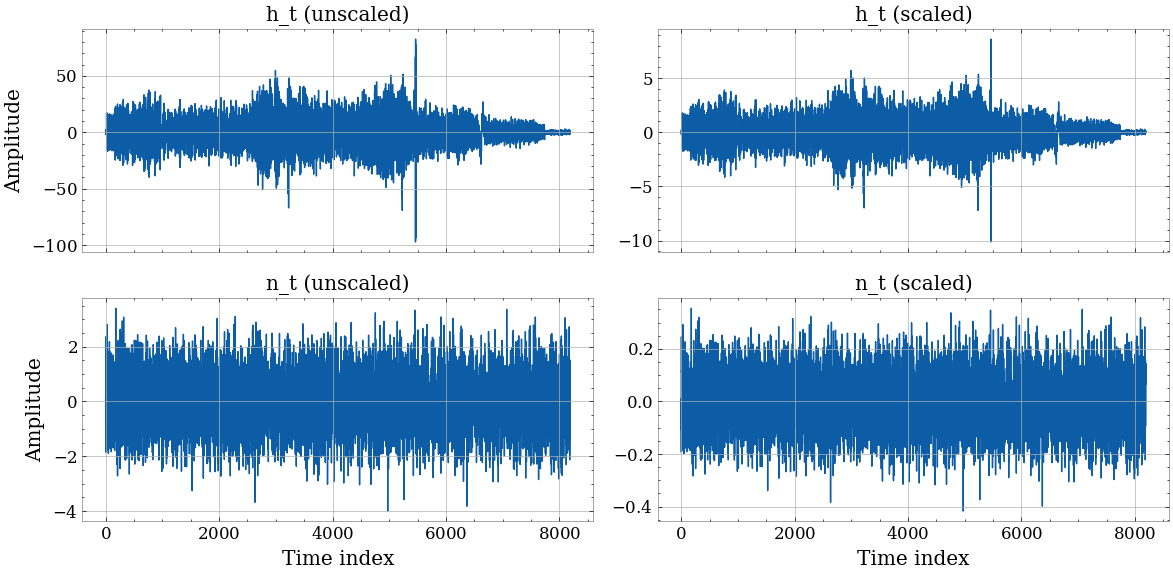

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)

idx = 0 
# h_t: unscaled vs scaled
axes[0, 0].plot(h_t[idx])
axes[0, 0].set_title("h_t (unscaled)")
axes[0, 0].set_ylabel("Amplitude")

axes[0, 1].plot(h_t_scaled[idx])
axes[0, 1].set_title("h_t (scaled)")

# n_t: unscaled vs scaled
axes[1, 0].plot(n_t[idx])
axes[1, 0].set_title("n_t (unscaled)")
axes[1, 0].set_ylabel("Amplitude")
axes[1, 0].set_xlabel("Time index")

axes[1, 1].plot(n_t_scaled[idx])
axes[1, 1].set_title("n_t (scaled)")
axes[1, 1].set_xlabel("Time index")

plt.tight_layout()
plt.show()

## Reconstruct simulated glitches

In [28]:
from pycbc.filter.matchedfilter import match
# All other imports are already loaded from the imports cell above

In [29]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
SAMPLE_RATE = 4096
NYQUIST_FREQ = SAMPLE_RATE // 2
T_MIN, T_MAX = 0.125, 2
T = 2.0
T_INJ = T / 2
LENGTH = int(T * SAMPLE_RATE)
NUM_SAMPLES_PER_CLASS = 5
SNR_MIN, SNR_MAX = 7.5, 100

## Make data for reconstruction

In [30]:
glitch_data = {}

# Generate glitch data for regular signals
signal_types = list(signal_function_map.keys())
for signal_type in signal_types:

    # Generate glitch data for each signal type
    glitch_data[signal_type] = generate_glitch_data(signal_type, gaussian_noise_samples, signal_function_map, bilby_noise=BILBY_NOISE)


100%|██████████| 10/10 [00:00<00:00, 3155.51it/s]


In [31]:
glitch_data.keys()

dict_keys(['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown'])

In [32]:
glitch_data['chirp'].keys()

dict_keys(['glitches_ts', 'clean_glitch_subtract', 'noisy_glitch_ts', 'pure_noise_ts', 'snr'])

## Loading the DeepExtractor model trained on bilby noise

Note: loading the model can take a few minutes at the first execution

In [33]:
model_name = 'DeepExtractor_257'

# Load model with bilby noise weights — downloads automatically from Hugging Face Hub
# if not found locally. Paired with scaler_bilby.pkl.
model = load_torch_model(
    model_name,
    {model_name: UNET2D(in_channels=2, out_channels=2)},
    device=DEVICE,
    checkpoint_filename=CHECKPOINT_BILBY,
)
print(f"Model loaded: {model is not None}")

INFO:deepextractor.utils.checkpoints:Downloading DeepExtractor_257/checkpoint_best_bilby_noise_base.pth.tar from tomdooney/deepextractor ...
INFO:httpx:HTTP Request: HEAD https://huggingface.co/tomdooney/deepextractor/resolve/main/DeepExtractor_257/checkpoint_best_bilby_noise_base.pth.tar "HTTP/1.1 302 Found"
INFO:deepextractor.utils.checkpoints:Successfully loaded model: DeepExtractor_257


Model loaded: True


In [34]:
# Scaler already loaded above — nothing to do here

In [35]:
# apply_stft, apply_istft, prepare_data_for_stft are imported from deepextractor.evaluation.simulate

In [22]:
# STFT params to get 257x257 spectrograms, this gave best results in experiments

n_fft = 256*2  # FFT window size
win_length = n_fft//8  # Window length, same as n_fft for full window
hop_length = win_length // 2  # Hop length for overlap, commonly n_fft // 4
window = torch.hann_window(win_length)  # Hann window for smoother STFT


In [36]:
model_data_dict = {}
for signal_type, data in glitch_data.items():
    noisy_glitch_ts_scaled_stft, noisy_glitch_ts_scaled, pure_noise_ts_scaled = prepare_data_for_stft(data, scaler, n_fft, hop_length, win_length, window)
    noisy_glitch_ts = np.asarray(data['noisy_glitch_ts'])
    pure_noise_ts = np.asarray(data['pure_noise_ts'])
    
    metrics_dict = {'match_background': [], 'match_glitch': [], 'mismatch_glitch': []}
    extracted_signals, background_output = [], []
    
    for m in range(0, len(noisy_glitch_ts_scaled_stft), BATCH_SIZE):
        batch_noisy_glitch_ts_scaled_stft_tensor = noisy_glitch_ts_scaled_stft[m:m+BATCH_SIZE].to(DEVICE)
        noisy_glitch_ts_batch = noisy_glitch_ts[m:m+BATCH_SIZE]
        pure_noise_ts_batch = pure_noise_ts[m:m+BATCH_SIZE]
        clean_glitch_subtract_batch = data['clean_glitch_subtract'][m:m+BATCH_SIZE]
    
        with torch.no_grad():
            output_val = model(batch_noisy_glitch_ts_scaled_stft_tensor.squeeze())
    
        # output_val_np_stft = output_val.cpu().numpy().squeeze()
        output_val_np_istft = apply_istft(output_val, n_fft, hop_length, win_length, window).cpu().numpy().squeeze()
        backgrounds_val_inverse = scaler.inverse_transform(output_val_np_istft.reshape(-1, output_val_np_istft.shape[-1])).reshape(output_val_np_istft.shape)
    
        Difference_ts = noisy_glitch_ts_batch - backgrounds_val_inverse
    
        for k in range(len(Difference_ts)):
            extracted_signals.append(Difference_ts[k])
            background_output.append(backgrounds_val_inverse[k])
    
            match_background = calculate_match(pure_noise_ts_batch[k], backgrounds_val_inverse[k])
            match_glitch = calculate_match(clean_glitch_subtract_batch[k], Difference_ts[k])
            mismatch_glitch = (1-match_glitch)*100
            
            metrics_dict['match_background'].append(match_background)
            metrics_dict['match_glitch'].append(match_glitch)
            metrics_dict['mismatch_glitch'].append(mismatch_glitch)
    
    model_data_dict[signal_type] = {
        'metrics': metrics_dict,
        'time_series': {
            'extracted_glitches': [ts.tolist() for ts in extracted_signals],
            'background_outputs': [ts.tolist() for ts in background_output]
        }
    }

### Below you can see example reconstructions with the groundtruth glitch overlayed. Mismatch performance is shown at the top of each plot 

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


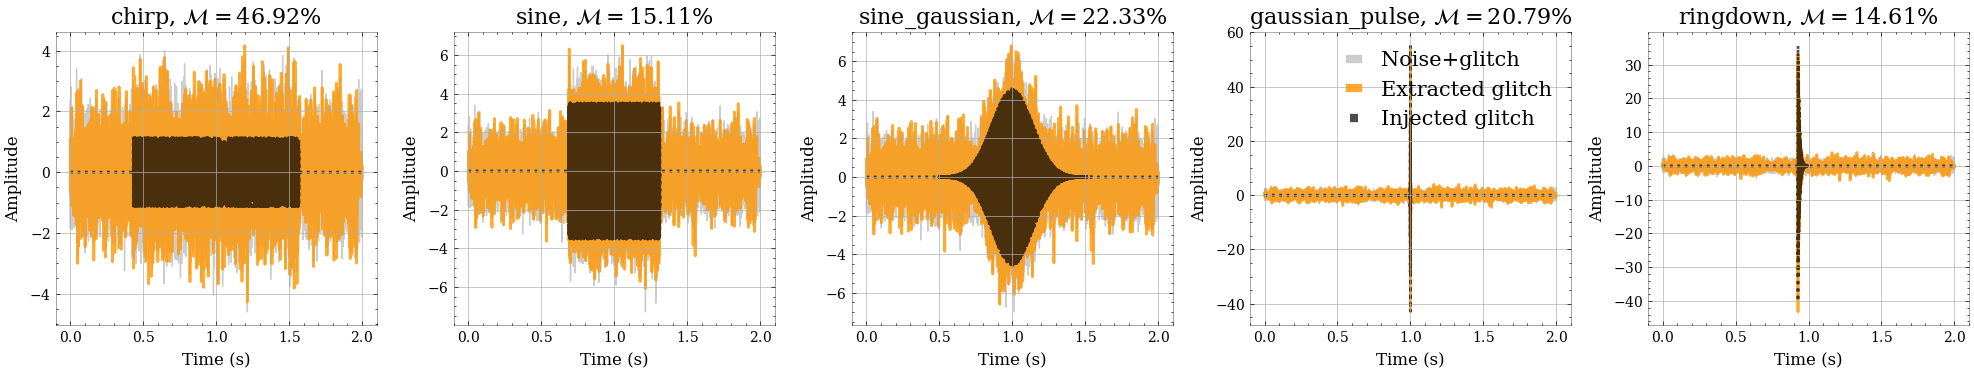

In [37]:
# Sample signal classes (from your dict keys)
signal_classes = ['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown']

# Create a 4x3 grid of subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 4 rows, 3 columns

# Flatten axes for easier iteration
axes = axes.flatten()

# Assuming `data_dict` contains the data
for i, signal_class in enumerate(signal_classes):
    # Extract data for the current signal class (using the first example, index 0)
    noisy_glitch_ts = glitch_data[signal_class]['noisy_glitch_ts'][0]
    clean_glitch_subtract = glitch_data[signal_class]['clean_glitch_subtract'][0]
    extracted_glitches = model_data_dict[signal_class]['time_series']['extracted_glitches'][0]
    match_result = model_data_dict[signal_class]['metrics']['match_glitch'][0]
    mismatch_result = (1-match_result)*100

    # Generate time array
    t = np.linspace(0, 2, len(clean_glitch_subtract))

    # Select the appropriate axis
    ax = axes[i]

    # Plot signals
    ax.plot(t, noisy_glitch_ts, c='gray', label='Noise+glitch', alpha=0.4)
    ax.plot(t, extracted_glitches, label='Extracted glitch', c='C2', linewidth=2, alpha=0.8)
    ax.plot(t, clean_glitch_subtract, label='Injected glitch', c='k', linestyle=':', linewidth=2, alpha=0.7)

    # Set titles, labels, and formatting
    ax.set_title(rf"{signal_class}, $\mathcal{{M}} = {np.round(mismatch_result, 2)}\%$", fontsize=16)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True)

    # Add legend only to the first subplot for clarity
    if i == 3:
        ax.legend(loc='upper right', fontsize=15)

# Remove unused subplots (if any)
for j in range(len(signal_classes), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

## Let's now generate noise for Virgo and repeat. We will see how the LIGO-trained model performs

In [38]:
gaussian_noise_samples_virgo = generate_gaussian_noise(MEAN, STD_DEV, NUM_SAMPLES, (LENGTH,), BILBY_NOISE, detector='V1')

glitch_data_virgo = {}

# Generate glitch data for regular signals
signal_types = list(signal_function_map.keys())
for signal_type in signal_types:

    # Generate glitch data for each signal type
    glitch_data_virgo[signal_type] = generate_glitch_data(signal_type, gaussian_noise_samples_virgo, signal_function_map, bilby_noise=BILBY_NOISE)


100%|██████████| 10/10 [00:00<00:00, 4591.47it/s]


In [39]:
model_data_dict_virgo = {}
for signal_type, data in glitch_data_virgo.items():
    noisy_glitch_ts_scaled_stft, noisy_glitch_ts_scaled, pure_noise_ts_scaled = prepare_data_for_stft(data, scaler, n_fft, hop_length, win_length, window)
    noisy_glitch_ts = np.asarray(data['noisy_glitch_ts'])
    pure_noise_ts = np.asarray(data['pure_noise_ts'])
    
    metrics_dict = {'match_background': [], 'match_glitch': [], 'mismatch_glitch': []}
    extracted_signals, background_output = [], []
    
    for m in range(0, len(noisy_glitch_ts_scaled_stft), BATCH_SIZE):
        batch_noisy_glitch_ts_scaled_stft_tensor = noisy_glitch_ts_scaled_stft[m:m+BATCH_SIZE].to(DEVICE)
        noisy_glitch_ts_batch = noisy_glitch_ts[m:m+BATCH_SIZE]
        pure_noise_ts_batch = pure_noise_ts[m:m+BATCH_SIZE]
        clean_glitch_subtract_batch = data['clean_glitch_subtract'][m:m+BATCH_SIZE]
    
        with torch.no_grad():
            output_val = model(batch_noisy_glitch_ts_scaled_stft_tensor.squeeze())
    
        # output_val_np_stft = output_val.cpu().numpy().squeeze()
        output_val_np_istft = apply_istft(output_val, n_fft, hop_length, win_length, window).cpu().numpy().squeeze()
        backgrounds_val_inverse = scaler.inverse_transform(output_val_np_istft.reshape(-1, output_val_np_istft.shape[-1])).reshape(output_val_np_istft.shape)
    
        Difference_ts = noisy_glitch_ts_batch - backgrounds_val_inverse
    
        for k in range(len(Difference_ts)):
            extracted_signals.append(Difference_ts[k])
            background_output.append(backgrounds_val_inverse[k])
    
            match_background = calculate_match(pure_noise_ts_batch[k], backgrounds_val_inverse[k])
            match_glitch = calculate_match(clean_glitch_subtract_batch[k], Difference_ts[k])
            mismatch_glitch = (1-match_glitch)*100
            
            metrics_dict['match_background'].append(match_background)
            metrics_dict['match_glitch'].append(match_glitch)
            metrics_dict['mismatch_glitch'].append(mismatch_glitch)
    
    model_data_dict_virgo[signal_type] = {
        'metrics': metrics_dict,
        'time_series': {
            'extracted_glitches': [ts.tolist() for ts in extracted_signals],
            'background_outputs': [ts.tolist() for ts in background_output]
        }
    }

In [40]:
glitch_data_virgo.keys()

dict_keys(['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown'])

In [ ]:
from scipy.optimize import curve_fit
from gwpy.timeseries import TimeSeries

# Optional: glitchfind for p-value analysis (install separately if needed)
try:
    from dqrtasks.glitchfind.glitchfind import _monoLog, p_val
    HAS_GLITCHFIND = True
except ImportError:
    HAS_GLITCHFIND = False
    print("glitchfind not installed — p-value analysis cells will be skipped.")

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


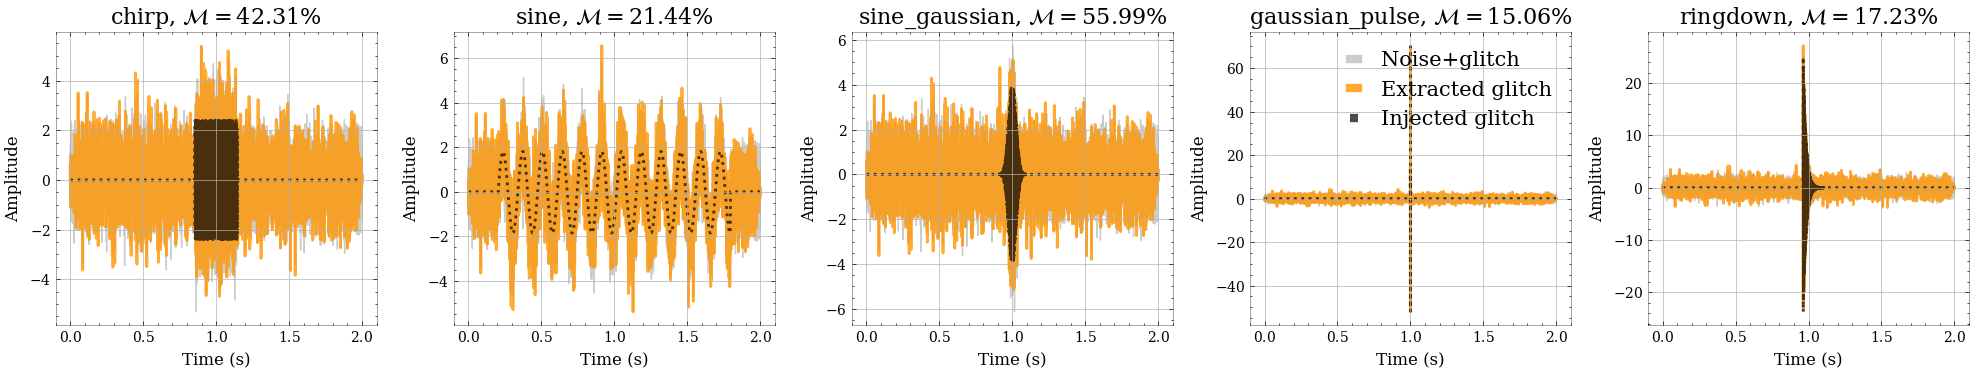

In [42]:
# Sample signal classes (from your dict keys)
signal_classes = ['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown']

# Create a 4x3 grid of subplots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))  # 4 rows, 3 columns

# Flatten axes for easier iteration
axes = axes.flatten()

# Assuming `data_dict` contains the data
for i, signal_class in enumerate(signal_classes):
    # Extract data for the current signal class (using the first example, index 0)
    noisy_glitch_ts = glitch_data_virgo[signal_class]['noisy_glitch_ts'][0]
    clean_glitch_subtract = glitch_data_virgo[signal_class]['clean_glitch_subtract'][0]
    extracted_glitches = model_data_dict_virgo[signal_class]['time_series']['extracted_glitches'][0]
    match_result = model_data_dict_virgo[signal_class]['metrics']['match_glitch'][0]
    mismatch_result = (1-match_result)*100

    # Generate time array
    t = np.linspace(0, 2, len(clean_glitch_subtract))

    # Select the appropriate axis
    ax = axes[i]

    # Plot signals
    ax.plot(t, noisy_glitch_ts, c='gray', label='Noise+glitch', alpha=0.4)
    ax.plot(t, extracted_glitches, label='Extracted glitch', c='C2', linewidth=2, alpha=0.8)
    ax.plot(t, clean_glitch_subtract, label='Injected glitch', c='k', linestyle=':', linewidth=2, alpha=0.7)

    # Set titles, labels, and formatting
    ax.set_title(rf"{signal_class}, $\mathcal{{M}} = {np.round(mismatch_result, 2)}\%$", fontsize=16)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Amplitude', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(True)

    # Add legend only to the first subplot for clarity
    if i == 3:
        ax.legend(loc='upper right', fontsize=15)

# Remove unused subplots (if any)
for j in range(len(signal_classes), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Sample signal classes (from your dict keys)
signal_classes = ['chirp', 'sine', 'sine_gaussian', 'gaussian_pulse', 'ringdown']

# --- Histogram/Q-transform parameters ---
q_low, q_high = 4, 20
f_low, f_high = 0.005, 1.5
min_bin, max_bin = 2.0, 42.0
fit_bins = 15
bins = np.linspace(min_bin, max_bin, int((max_bin - min_bin) * 2 + 1))
bin_mids = (bins[:-1] + bins[1:]) / 2
p0 = (3, 0.5)

sample_rate = 4  # Hz
gps_time = 1234567890.0  # replace with your real GPS time if needed

# --- Create a 2x5 grid (top: time series, bottom: histograms) ---
fig, axes = plt.subplots(
    2, 5,
    figsize=(22, 7),
    sharex='row',
    gridspec_kw={"height_ratios": [2.2, 1.4], "hspace": 0.25, "wspace": 0.25},
)

for i, signal_class in enumerate(signal_classes):
    ax_ts = axes[0, i]
    ax_hist = axes[1, i]

    # -----------------------------
    # Top row: your time series plot
    # -----------------------------
    noisy_glitch_ts = glitch_data_virgo[signal_class]['noisy_glitch_ts'][0]
    clean_glitch_subtract = glitch_data_virgo[signal_class]['clean_glitch_subtract'][0]
    extracted_glitches = model_data_dict_virgo[signal_class]['time_series']['extracted_glitches'][0]
    match_result = model_data_dict_virgo[signal_class]['metrics']['match_glitch'][0]
    mismatch_result = (1 - match_result) * 100

    t = np.linspace(0, 2, len(clean_glitch_subtract))

    ax_ts.plot(t, noisy_glitch_ts, c='gray', label='Noise+glitch', alpha=0.4)
    ax_ts.plot(t, extracted_glitches, label='Extracted glitch', c='C2', linewidth=2, alpha=0.8)
    ax_ts.plot(t, clean_glitch_subtract, label='Injected glitch', c='k', linestyle=':', linewidth=2, alpha=0.7)

    ax_ts.set_title(rf"{signal_class}, $\mathcal{{M}} = {mismatch_result:.2f}\%$", fontsize=14)
    ax_ts.set_ylabel('Amplitude', fontsize=11)
    ax_ts.grid(True)

    if i == 0:
        ax_ts.legend(loc='upper right', fontsize=10)

    # ------------------------------------------------
    # Bottom row: histograms (noise / noise+glitch / bg-sub)
    # ------------------------------------------------
    # Adapt these three lines to your actual dicts (using your example paths):
    timeseries_original_noise = np.asarray(glitch_data_virgo[signal_class]['pure_noise_ts'][0])
    timeseries_noisy_glitch = np.asarray(glitch_data_virgo[signal_class]['noisy_glitch_ts'][0])
    timeseries_background_subtracted = np.asarray(
        model_data_dict_virgo[signal_class]['time_series']['background_outputs'][0]
    )

    timeseries_list = [
        ("Original Noise", timeseries_original_noise),
        ("Noise+Glitch", timeseries_noisy_glitch),
        ("After Subtraction", timeseries_background_subtracted),
    ]
    colors = ["C0", "C1", "C2"]

    duration = len(timeseries_original_noise) / sample_rate

    # compute+plot histograms + fits
    p_text_lines = []
    for (label, ts_data), color in zip(timeseries_list, colors):
        ts = TimeSeries(ts_data, sample_rate=sample_rate, t0=gps_time - duration / 2)

        qgram = ts.q_gram(
            qrange=(q_low, q_high),
            snrthresh=2,
            frange=(f_low, f_high),
            mismatch=0.5,
        ).filter(
            "time > %.2f" % (gps_time - duration / 2),
            "time < %.2f" % (gps_time + duration / 2),
        )

        energies = qgram["energy"]

        n, _, _ = ax_hist.hist(
            energies,
            bins=bins,
            density=True,
            alpha=0.35,
            histtype="stepfilled",
            color=color,
            label=label if i == 0 else None,  # only label once for global legend
        )

        if HAS_GLITCHFIND:
            # Fit monoLog model and compute p-value
            fit_yvals = np.ma.log(n[:fit_bins]).filled(-999)
            params, _ = curve_fit(_monoLog, bin_mids[:fit_bins], fit_yvals, p0)
            m, t0_fit = params

            fit_curve = np.exp(_monoLog(bin_mids, m, t0_fit))
            ax_hist.plot(bin_mids, fit_curve, linestyle="--", color=color, linewidth=1.2)

            max_energy = np.max(energies)
            p = p_val(max_energy, len(energies), (m, t0_fit))
            print(p)
            p_text_lines.append(f"{label}: p={p:.2f}")

    ax_hist.set_yscale("log")
    ax_hist.grid(True, which="both", alpha=0.3)
    ax_hist.set_xlabel("Q energy", fontsize=11)
    if i == 0:
        ax_hist.set_ylabel("PDF", fontsize=11)

    if HAS_GLITCHFIND:
        # Put the p-values inside each histogram panel (top-left)
        ax_hist.text(
            0.02, 0.98,
            "\n".join(p_text_lines),
            transform=ax_hist.transAxes,
            va="top", ha="left",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="none")
        )

# Global legend for histograms (from the first column labels)
handles, labels = axes[1, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=11)

axes[0, 0].set_xlabel("Time (s)", fontsize=11)  # optional; you can set per-axis if preferred
for i in range(5):
    axes[0, i].set_xlabel("Time (s)", fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### The model already performs pretty well. Let's look at the PSDs for both detectors

In [ ]:
# Create bilby interferometers (empty = no data, just geometry + default PSD model)
ifos = bilby.gw.detector.InterferometerList([
    bilby.gw.detector.get_empty_interferometer("L1"),
    bilby.gw.detector.get_empty_interferometer("V1"),
])

# Frequency grid for plotting
fmin, fmax = 10, 1600
freqs = np.logspace(np.log10(fmin), np.log10(fmax), 2000)

plt.figure(figsize=(10, 6))

for ifo in ifos:
    psd_vals = ifo.power_spectral_density.get_power_spectral_density_array(freqs)
    plt.plot(freqs, psd_vals, label=f"{ifo.name} (bilby PSD)")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Frequency [Hz]", fontsize=22)
plt.ylabel("Power Spectral Density [1/Hz]", fontsize=22)
plt.xlim((fmin, fmax))
plt.ylim(bottom=1e-49)
plt.legend(fontsize=16)
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

### The above shows how the simulated PSDs are quite similar, so DeepExtractor trained on simulated LIGO noise can handle the simulated Virgo noise reasonably well

### For real noise, the results may vary considerably more